# Equilibration Check for Umbrella Sampling Windows

This notebook checks the equilibration of each window (conformation) before proceeding to umbrella sampling. It loads the `pullx.xvg` files for each equilibrated window, concatenates the data, and visualizes the distribution of the collective variable (CV) positions using a kernel density estimate (KDE) plot. This helps ensure that each window is properly equilibrated and that the CV positions are stable.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# List of conformations (windows) to check.
# These are the frame numbers or identifiers for each window extracted from the SMD simulation.
confs = [int(i) for i in np.array([   0.,   47.,  241.,  331.,  390.,  502.,  683.,  717.,  823.,
       1027., 1131., 1239., 1301., 1347., 1386., 1473., 1546.])]

## Load and concatenate data

In [ ]:
# Initialize a list to store the data from each window's pullx.xvg file
dats = []

# Loop over each conformation
for c in confs:
    # Load the pullx.xvg file for the current window
    # This file contains the position of the collective variable (CV) over time during equilibration
    file = f'conf{c}_eq_pullx.xvg'
    dat = np.loadtxt(file, comments=['@', '#'])

    # Append the data to the list
    dats.append(dat)

# Concatenate the data from all windows into a single array
dats = np.concatenate(dats, axis=0)

# Convert the array to a pandas DataFrame for easier manipulation
# Columns: 'frame' (simulation frame), 'position' (CV position)
dats = pd.DataFrame(dats, columns=['frame', 'position'])

# Add a column to track which conformation each row belongs to
# This is useful for plotting and analysis
dats['conformation'] = np.repeat(confs, len(dats))


## Visualization

The KDE plot shows the distribution of the collective variable (CV) positions for each window during equilibration.

A well-equilibrated window will show a stable, narrow distribution of CV positions.
If any window shows a broad or bimodal distribution, it may indicate poor equilibration and require further investigation.

In [ ]:
# Select all data for visualization
# Optionally, you can focus on a subset of conformations by uncommenting the following line:
# d = dats[dats['conformation'].isin(confs[6:15])]
d = dats

# Create a KDE plot to visualize the distribution of CV positions for each window
plt.figure(figsize=(10, 6))
sns.kdeplot(data=d, x='position',
            hue='conformation',
            palette=sns.color_palette("husl", len(confs)))

plt.legend(title='Conformation')

plt.xlabel('Collective Variable Position (nm)')
plt.ylabel('Density')
plt.title('Distribution of CV Positions During Equilibration')

plt.show()

In [58]:
dats = []

for c in confs:
    file = f'conf{c}_eq_pullx.xvg'
    dat = np.loadtxt(file, comments=['@', '#'])
    dats.append(dat)
    
dats = np.concatenate(dats, axis=0)

dats = pd.DataFrame(dats, columns=['frame', 'position'])
dats['conformation'] = np.repeat(confs, 1001)

/tmp/ipykernel_376747/2021588800.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


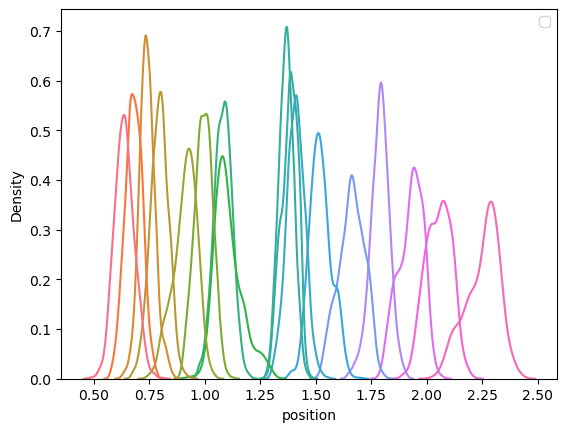

In [59]:
# d = dats[dats['conformation'].isin(confs[6:15])]
d = dats

plt.subplot()
sns.kdeplot(data=d, x='position', 
            hue='conformation', 
            palette=sns.color_palette("husl", len(confs)))
plt.legend()
